# Helpers

In [9]:
import seaborn as sns
from pymatreader import read_mat
import os
import pandas as pd
import numpy as np
from nilearn import plotting
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
from scipy import stats
from collections import defaultdict
import networkx as nx
from scipy.linalg import expm, eigvals

def compute_extra_metrics(df, rho=0.99):
    """
    Añade C_unw, C_w y comm_mean.
    Aplica normalización espectral estricta para evitar overflow en expm.
    """
    c_unw_list, c_w_list, comm_list = [], [], []
    
    for _, row in df.iterrows():
        A = row.connectome.copy()
        np.fill_diagonal(A, 0)
        N = A.shape[0]
        
        # Redes para clustering
        G_unw = nx.from_numpy_array((A > 0).astype(float))
        G_w   = nx.from_numpy_array(A)
        
        c_unw_list.append(nx.average_clustering(G_unw))
        c_w_list.append(nx.average_clustering(G_w, weight='weight'))

        # Normalización espectral y comunicabilidad
        sr = np.abs(eigvals(A)).max()
        A_norm = A * (rho / sr) if sr > 0 else A
        
        try:
            C = expm(A_norm)
            comm = (C.sum() - np.trace(C)) / (N * (N - 1))
        except Exception:
            comm = np.nan
            
        comm_list.append(comm)

    df = df.copy()
    df['C_unw']     = c_unw_list
    df['C_w']       = c_w_list
    df['comm_mean'] = comm_list
    
    return df


def ddw_group_rep(connectomes, dist_mat, hemi, n_bins=22, rng=None):
    """
    Construye un conectoma representativo (DDW) de un grupo de sujetos.
    Mantiene la densidad intra/inter-hemisférica por bins de distancia.
    Asigna pesos mediante muestreo aleatorio de la cohorte empírica.
    """
    if rng is None: 
        rng = np.random.default_rng(42)
        
    N_subs = len(connectomes)
    N_nodes = connectomes[0].shape[0]
    
    # 1. Extraer estadísticas empíricas (Frecuencia, Peso medio, Pool de pesos)
    freq = np.zeros((N_nodes, N_nodes))
    avg_w = np.zeros((N_nodes, N_nodes))
    weights_pool = { (i,j): [] for i in range(N_nodes) for j in range(i+1, N_nodes) }
    
    for adj in connectomes:
        A = np.triu(adj, 1) # Asegurar red no dirigida
        freq += (A > 0).astype(int)
        avg_w += A
        
        rows, cols = A.nonzero()
        for r, c in zip(rows, cols):
            weights_pool[(r,c)].append(A[r,c])
            
    avg_w = np.divide(avg_w, freq, out=np.zeros_like(avg_w), where=freq!=0)
    group_rep = np.zeros((N_nodes, N_nodes))
    
    # 2. Procesar enlaces separando intra e inter-hemisféricos
    for is_intra in [True, False]:
        mask_hemi = (hemi == 1) if is_intra else (hemi == 0)
        mask_valid = np.triu(mask_hemi, 1) & (freq > 0)
        
        if not np.any(mask_valid): continue
            
        valid_edges = np.argwhere(mask_valid)
        distances = dist_mat[valid_edges[:,0], valid_edges[:,1]]
        
        # Bins equitativos basados en percentiles de distancia
        bins = np.percentile(distances, np.linspace(0, 100, n_bins+1))
        bins[-1] += 1e-5 
        edge_bin_idx = np.digitize(distances, bins) - 1
        
        # 3. Consenso topológico por bin
        for b in range(n_bins):
            idx_in_bin = np.where(edge_bin_idx == b)[0]
            if len(idx_in_bin) == 0: continue
                
            bin_edges = valid_edges[idx_in_bin]
            expected_edges = int(np.round(len(idx_in_bin) / N_subs))
            
            if expected_edges == 0: continue
            
            # Ordenar aristas: primary_key=frecuencia, secondary_key=peso_medio
            edge_stats = [(freq[u,v], avg_w[u,v], u, v) for u, v in bin_edges]
            edge_stats.sort(key=lambda x: (x[0], x[1]), reverse=True)
            
            selected_edges = edge_stats[:expected_edges]
            
            # 4. Asignación de pesos (Muestreo Aleatorio DDW)
            for _, _, u, v in selected_edges:
                sampled_weight = rng.choice(weights_pool[(u,v)])
                group_rep[u, v] = sampled_weight
                group_rep[v, u] = sampled_weight 
                
    return group_rep

 
def null_model_kY(ks=None):
    """
    Devuelve arrays de referencia para el scatter kY(k):
      kY_null (media), kY_null_hi (media+2σ), kY_null_lo (=1),
      kY_hom (totalmente homogéneo), kY_het (totalmente heterogéneo)
    """
    if ks is None:
        ks = np.arange(2, 90)
    kY_null = 2 * ks / (ks + 1)
    term1   = (20 + 4*ks) / ((ks+1) * (ks+2) * (ks+3))
    term2   = 4 / (ks+1)**2
    var_kY  = (ks**2) * (term1 - term2)
    return dict(
        ks      = ks,
        kY_null = kY_null,
        kY_hi   = kY_null + 2*np.sqrt(var_kY),
        kY_lo   = np.ones_like(ks, dtype=float),
        kY_hom  = np.ones_like(ks, dtype=float),
        kY_het  = ks.astype(float),
    )
 

def make_ds_colors(ds_list):
    """Devuelve dict {dataset_id: color} con tab10."""
    cmap = plt.cm.tab10
    return {ds: cmap(i / max(len(ds_list) - 1, 1)) for i, ds in enumerate(ds_list)}
 
 
# ── Métricas de red ──────────────────────────────────────────────────────────
 
def node_metrics(adj):
    """
    Métricas por nodo para una matriz de adyacencia pesada.
    Devuelve: k (degree), s (strength), Y (disparity), kY (k·Y)
    """
    A = adj.copy(); np.fill_diagonal(A, 0)
    k  = (A > 0).sum(axis=1).astype(float)
    s  = A.sum(axis=1)
    p  = A / np.where(s > 0, s, 1.)[:, None]
    Yi = (p**2).sum(axis=1)
    #average weight of a node
    wi = np.divide(s, k, out=np.zeros_like(s, dtype=float), where=k>0)
    
    
    return k, s, Yi, k * Yi, wi
 
 
def subject_metrics(conn_array, N_roi=90):
    """
    Métricas escalares por sujeto para un array de conectomas.
    Devuelve DataFrame con: density, strength, degree, Y_obs, kY_obs, Y_null, Ratio
    """
    n = len(conn_array)
    D, S, K, Y, kY, YN, R = [np.zeros(n) for _ in range(7)]
    for i, raw in enumerate(conn_array):
        adj = raw.copy(); np.fill_diagonal(adj, 0)
        k, s, Yi, kYi, wi = node_metrics(adj)
        v = k > 1
        if v.sum() == 0:
            D[i] = S[i] = K[i] = Y[i] = kY[i] = YN[i] = R[i] = np.nan
            continue
        D[i]  = (adj > 0).sum() / (N_roi * (N_roi - 1))
        S[i]  = s[v].mean()
        K[i]  = k[v].mean()
        Y[i]  = Yi[v].mean()
        kY[i] = kYi[v].mean()
        YN[i] = (2. / (k[v] + 1)).mean()
        R[i]  = (Yi[v] / (2. / (k[v] + 1))).mean()
    return pd.DataFrame(dict(density=D, strength=S, degree=K,
                             Y_obs=Y, kY_obs=kY, Y_null=YN, Ratio=R, ))
 
 
def subj_stats(adj):
    """Stats de red (min/max/mu/var de k, w, s) para un conectoma. Devuelve dict."""
    A = adj.copy(); np.fill_diagonal(A, 0)
    k = (A > 0).sum(axis=1).astype(float)
    s = A.sum(axis=1); w = A[A > 0]; v = k > 0
    if v.sum() == 0 or len(w) == 0:
        return {}
    return {'N': int(v.sum()),
            'k_min': k[v].min(), 'k_max': k[v].max(),
            'k_mu': k[v].mean(), 'k_var': k[v].var(),
            'w_min': w.min(),    'w_max': w.max(),
            'w_mu':  w.mean(),   'w_var': w.var(),
            's_min': s[v].min(), 's_max': s[v].max(),
            's_mu':  s[v].mean(),'s_var': s[v].var()}
 
 
def by_degree(conn_list):
    """
    Para cada clase de degree k, calcula media de Y, kY y Ratio
    sobre todos los conectomas de conn_list.
    Devuelve dict {k: (Y_mean, Ratio_mean, kY_mean, n_connectomes)}
    """
    acc = defaultdict(lambda: {'Y': [], 'R': [], 'kY': [], 'nc': 0})
    for adj in conn_list:
        k, s, Yi, kYi, wi = node_metrics(adj)
        seen = set()
        for ki in np.unique(k[k > 1].astype(int)):
            m = k == ki
            acc[ki]['Y'].append(Yi[m].mean())
            acc[ki]['kY'].append(kYi[m].mean())   # ← fix: era kYi[i]
            acc[ki]['R'].append((Yi[m] / (2. / (ki + 1))).mean())
            seen.add(ki)
        for ki in seen:
            acc[ki]['nc'] += 1
    return {ki: (np.mean(v['Y']), np.mean(v['R']), np.mean(v['kY']), v['nc'])
            for ki, v in acc.items()}
    
    
def _logbins_hist(vals, n_bins=25):
    """Histograma en escala log con centros geométricos. Devuelve (centros, densidad)."""
    vals = vals[vals > 0]
    if len(vals) < 2:
        return np.array([]), np.array([])
    bins = np.logspace(np.log10(vals.min() + 1e-15),
                       np.log10(vals.max() + 1e-15), n_bins + 1)
    h, e = np.histogram(vals, bins=bins, density=True)
    c = np.sqrt(e[:-1] * e[1:])
    return c[h > 0], h[h > 0]
 

def plot_distributions(subjects, ax_pw, ax_ps, ax_cpk, ax_sk,
                       color='steelblue', alpha=0.5, ms=2, lw=0.8,
                       ks_ref=None, show_Y0=True):
    """
    Acumula distribuciones normalizadas y dibuja mediana ± IQR (banda).
    Normalización: w/w_max, s/s_max por sujeto. x de CCDF y s(k): k/k_max.
    """
    pw_acc  = defaultdict(list)   # bin_center → list of densities
    ps_acc  = defaultdict(list)
    pk_acc  = defaultdict(list)
    sk_acc  = defaultdict(list)

    W_BINS = np.logspace(-4, 0, 26)   # normalized bins [0,1]
    S_BINS = np.logspace(-4, 0, 26)

    for row in subjects:
        adj = (row.connectome if hasattr(row, 'connectome') else row).copy()
        np.fill_diagonal(adj, 0)
        k, s, Yi, kYi, wi = node_metrics(adj)
        w = adj[adj > 0]; v = k > 1
        if v.sum() == 0:
            continue

        wmax = w.max() if w.max() > 0 else 1
        smax = s[v].max() if s[v].max() > 0 else 1
        kmax = k[v].max() if k[v].max() > 0 else 1

        # P(w) normalized
        wn = w / wmax
        h, e = np.histogram(wn[wn > 0], bins=W_BINS, density=True)
        c = np.sqrt(e[:-1] * e[1:])
        for ci, hi in zip(c[h > 0], h[h > 0]):
            pw_acc[ci].append(hi)

        # P(s) normalized
        sn = s[v] / smax
        h, e = np.histogram(sn[sn > 0], bins=S_BINS, density=True)
        c = np.sqrt(e[:-1] * e[1:])
        for ci, hi in zip(c[h > 0], h[h > 0]):
            ps_acc[ci].append(hi)

        # CCDF and s(k) — k normalized by k_max
        ku, kc = np.unique(k[v].astype(int), return_counts=True)
        pk = kc / kc.sum()
        for ki, pi in zip(ku, pk):
            pk_acc[ki / kmax].append(pi)
            sk_acc[ki / kmax].append(s[k == ki].mean() / smax)

    def _plot_band(ax, acc_dict, color, alpha, lw):
        if not acc_dict:
            return
        xs = np.array(sorted(acc_dict))
        med = np.array([np.median(acc_dict[x]) for x in xs])
        q25 = np.array([np.percentile(acc_dict[x], 25) for x in xs])
        q75 = np.array([np.percentile(acc_dict[x], 75) for x in xs])
        ax.loglog(xs, med, '-', lw=lw + 0.2, alpha=min(alpha + 0.3, 1), color=color)
        ax.fill_between(xs, q25, q75, alpha=alpha * 0.4, color=color, linewidth=0)

    # CCDF needs cumulative from sorted k/k_max
    if pk_acc:
        ks = np.array(sorted(pk_acc))
        pk_med = np.array([np.median(pk_acc[x]) for x in ks])
        pk_q25 = np.array([np.percentile(pk_acc[x], 25) for x in ks])
        pk_q75 = np.array([np.percentile(pk_acc[x], 75) for x in ks])
        ccdf_med = np.cumsum(pk_med[::-1])[::-1]
        ccdf_q25 = np.cumsum(pk_q25[::-1])[::-1]
        ccdf_q75 = np.cumsum(pk_q75[::-1])[::-1]
        ccdf_med = ccdf_med / ccdf_med.max()   # fuerza a empezar en 1
        ccdf_q25 = ccdf_q25 / ccdf_q25.max()
        ccdf_q75 = ccdf_q75 / ccdf_q75.max()

        ax_cpk.loglog(ks, ccdf_med, '-', lw=lw + 0.2,
                      alpha=min(alpha + 0.3, 1), color=color)
        ax_cpk.fill_between(ks, ccdf_q25, ccdf_q75,
                            alpha=alpha * 0.4, color=color, linewidth=0)

    _plot_band(ax_pw, pw_acc, color, alpha, lw)
    _plot_band(ax_ps, ps_acc, color, alpha, lw)
    _plot_band(ax_sk, sk_acc, color, alpha, lw)

    ax_pw.set_xlabel('$w/w_{max}$');     ax_pw.set_ylabel('$P(w)$')
    ax_ps.set_xlabel('$s/s_{max}$');     ax_ps.set_ylabel('$P(s)$')
    ax_cpk.set_xlabel('$k/k_{max}$');    ax_cpk.set_ylabel('$P(K\\geq k)$')
    ax_sk.set_xlabel('$k/k_{max}$');     ax_sk.set_ylabel('$\\langle s/s_{max}\\rangle_k$')


# Data and parameters

In [12]:

plt.rcParams.update({
    'font.size':7,'axes.titlesize':7,'axes.labelsize':7,
    'xtick.labelsize':6,'ytick.labelsize':6,
    'lines.linewidth':0.9,'lines.markersize':2.5,'figure.dpi':150,
})



connectomes = read_mat('preprocdata/all_data.mat')['all_data']['connectomes']
demo        = pd.read_csv('preprocdata/demographics.csv')

FILTER_DS = [1,2,3,4,5,6,7,8,9]
mask = (demo['group']==1) & (demo['dataset'].isin(FILTER_DS))      
demo        = demo[mask].reset_index(drop=True)                   ###dejamos fuera los no neurotipicos
connectomes = connectomes[mask]

data = pd.DataFrame({'age':demo['age'], 'dataset':demo['dataset'],
                     'sex':demo['sex'], 'connectome':list(connectomes)})
data['decade'] = (data.age // 10 * 10).astype(int)

# Métricas escalares
data = pd.concat([data.reset_index(drop=True),
                  subject_metrics(connectomes)], axis=1)

# Colores y globals
ds_list = sorted(data.dataset.unique())
ND      = len(ds_list)
ds2col  = make_ds_colors(ds_list)
NUL     = null_model_kY()    # dict con ks, kY_null, kY_hi, kY_lo, kY_hom, kY_het

print(f'{len(data)} sujetos, {ND} datasets')

coords   = plotting.find_parcellation_cut_coords('./preprocdata/aal-SPM12/aal/atlas/AAL.nii')[:90]
dist_mat = cdist(coords, coords)
hemi     = np.zeros((90,90), dtype=int)
hemi[:45,:45] = 1; hemi[45:,45:] = 1
N_BINS   = 22
rng_ddw  = np.random.default_rng(42)
MIN_N    = 3



# Group representatives por dataset y edad (DDW)
grep_ageds = pd.DataFrame()
for ds in ds_list:
    for age in sorted(data[data.dataset==ds].age.unique()):
        sub = data[(data.dataset==ds) & (data.age==age)]
        # Requiere al menos 3 sujetos para un group representative con sentido
        if len(sub) < 3: continue
        gr = ddw_group_rep(list(sub.connectome), dist_mat, hemi, N_BINS, rng_ddw)
        metrics_gr = subject_metrics([gr])  # DataFrame con métricas del group representative
        # Extraemos metadatos del subconjunto actual (son constantes en 'sub')
        meta = pd.DataFrame({
            'age': [age],
            'dataset': [ds],
            'connectome': [gr]
        })
        
        # Concatenamos horizontalmente las métricas y los metadatos, luego al histórico
        row = pd.concat([metrics_gr.reset_index(drop=True), meta], axis=1)
        grep_ageds = pd.concat([grep_ageds, row], ignore_index=True)


# Group representatives por edad (DDW)
grep_age = pd.DataFrame()
for age in sorted(data.age.unique()):
    sub = data[data.age==age]
    if len(sub) < 3: continue
    
    gr = ddw_group_rep(list(sub.connectome), dist_mat, hemi, N_BINS, rng_ddw)
    metrics_gr = subject_metrics([gr])  # DataFrame con métricas del group representative
    meta = pd.DataFrame({
        'age': [age],
        'connectome': [gr]})
    row = pd.concat([metrics_gr.reset_index(drop=True), meta], axis=1)
    grep_age = pd.concat([grep_age, row], ignore_index=True)




compare_ds=[1,2,3,4,5,6,8,7,9]

sel_rows = []
for ds in compare_ds:
        sub = data[(data.dataset==ds)]
        if len(sub)==0: continue
        sel_rows.append(sub.loc[(sub.age - sub.age.median()).abs().idxmin()])
sel = pd.DataFrame(sel_rows)

groups = [{'subjects': [row], 'color': ds2col[row.dataset],
           'label': f'DS{row.dataset}', 'alpha':0.7, 'ms':3}
          for _, row in sel.iterrows()]

import pickle
with open('procdata/data.pkl', 'wb') as f:
    pickle.dump(data, f)

with open('procdata/grep_ageds.pkl', 'wb') as f:
    pickle.dump(grep_ageds, f)



c:\Users\Ale\miniconda3\envs\snakes\Lib\site-packages\pymatreader\utils.py:304: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(


3901 sujetos, 9 datasets


In [13]:

# ── Dataset mapping ───────────────────────────────────────────────────────────
DS_NAMES = {
    1: 'dHCP',
    2: 'BCP',
    3: 'CALM',
    4: 'RED',
    5: 'ACE',
    6: 'HCPd',
    7: 'HCPya',
    8: 'camCAN',
    9: 'HCPa',
}

# Figura 1

In [25]:
"""
Panel 1 — composite figure
══════════════════════════════════════════════════════════════════════════════
LAYOUT

        Left  (4 × 2)                 Right (4 rows, single col)
  ┌──────┬──────┐               ┌────────────────────────┐
  │ P(w) │ P(s) │  row 0        │  Brain connectome      │  row 0  (nilearn)
  ├──────┼──────┤               ├────────────────────────┤
  │knn_uw│knn_w │  row 1        │  Age histogram         │  row 1
  ├──────┼──────┤               ├────────────────────────┤
  │ C(k) │C^w(k)│  row 2        │  w(k) by decade        │  row 2  (medians only)
  ├──────┼──────┤               ├────────────────────────┤
  │ s(k) │ CCDF │  row 3        │  w(k) by decade + IQR  │  row 3  (with bands)
  └──────┴──────┘               └────────────────────────┘
               Shared legend — bottom strip, full width

NOTES
  · Raw weights throughout — no per-subject normalisation.
  · RIGHT 3 replaces the old "global w(k) + regression" panel.
    It shows the same quantity as RIGHT 2 but adds IQR bands.
  · Binning strategy for RIGHT 3 is a one-line swap (see _ACC_WK below).
"""

import os
import tempfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
from matplotlib.patches import Patch
from collections import defaultdict
from scipy.stats import linregress
import seaborn as sns

# ── project imports ───────────────────────────────────────────────────────────
# from helperfuncs import node_metrics
# from nilearn import plotting
# data       : pd.DataFrame  — columns: age, decade, dataset, connectome
# coords_90  : (90, 3) array — AAL region MNI coordinates
# ds2col     : {dataset_id: colour}
# DS_NAMES   : {dataset_id: label}

sns.set_theme(style='ticks', context='paper')

MIN_N = 3   # minimum subjects per decade to plot


# ══════════════════════════════════════════════════════════════════════════════
# 1.  DISTRIBUTION HELPERS  (P(w), P(s), knn, C(k), s(k), CCDF)
# ══════════════════════════════════════════════════════════════════════════════

_BINS = {
    'w':    np.logspace(-1, 5, 30),
    's':    np.logspace(0,  6, 30),
    'k':    np.logspace(0,  3, 25),
}


def _exp_histogram(values, bins):
    """Log-spaced density histogram; returns (centres, counts) for counts > 0."""
    counts, edges = np.histogram(values[values > 0], bins=bins, density=True)
    centres = np.sqrt(edges[:-1] * edges[1:])
    ok = counts > 0
    return centres[ok], counts[ok]


def _exp_profile(x, y, bins):
    """Mean of y within each log-spaced bin of x. Returns {centre: mean}."""
    centres = np.sqrt(bins[:-1] * bins[1:])
    idx = np.digitize(x, bins) - 1
    return {c: np.mean(y[idx == i])
            for i, c in enumerate(centres) if np.any(idx == i)}


def accumulate_distributions(subjects) -> dict:
    """
    Single-pass accumulation over an iterable of subjects.

    Returns accumulators for 8 panels (keyed by short name):
      pw, ps         — P(w), P(s)
      knn_uw, knn_w  — unweighted / weighted nearest-neighbour degree
      ck_uw, ck_w    — C(k) unweighted / weighted clustering
      sk             — s(k) strength–degree scaling
      cpk            — CCDF of k/k_max
    """
    pw_acc = ps_acc = knn_uw_acc = knn_w_acc = None   # initialised below
    pw_acc     = defaultdict(list)
    ps_acc     = defaultdict(list)
    knn_uw_acc = defaultdict(list)
    knn_w_acc  = defaultdict(list)
    ck_uw_acc  = defaultdict(list)
    ck_w_acc   = defaultdict(list)
    sk_acc     = defaultdict(list)
    cpk_acc    = defaultdict(list)
    raw_k, raw_s = [], []

    k_eval_norm = np.logspace(-2, 0, 40)   # fixed evaluation grid for CCDF

    for row in subjects:
        adj = (row.connectome if hasattr(row, 'connectome') else row).copy()
        np.fill_diagonal(adj, 0)

        k, s, Yi, kYi, wi = node_metrics(adj)
        w     = adj[adj > 0]
        valid = k > 1
        if valid.sum() == 0:
            continue

        k_v, s_v = k[valid], s[valid]
        k_pos     = k[k > 0]
        k2_over_k = np.mean(k_pos ** 2) / np.mean(k_pos)   # knn rescaling factor

        # --- all graph metrics via numpy (no NetworkX) -----------------------
        A   = (adj > 0).astype(np.float64)
        A2  = A @ A

        knn_uw = (A   @ k) / np.where(k > 0, k.astype(float), 1.0)
        knn_w  = (adj @ k) / np.where(s > 0, s, 1.0)

        denom_k = k * (k - 1)
        C_uw    = np.where(denom_k > 0, (A2 * A).sum(axis=1)   / denom_k, 0.0)
        denom_s = s * (k - 1)
        C_w     = np.where(denom_s > 0, (adj * A2).sum(axis=1) / denom_s, 0.0)

        raw_k.append(k_v);  raw_s.append(s_v)

        # P(w), P(s)
        for c, h in zip(*_exp_histogram(w,   _BINS['w'])): pw_acc[c].append(h)
        for c, h in zip(*_exp_histogram(s_v, _BINS['s'])): ps_acc[c].append(h)

        # knn  (normalised by <k²>/<k>)
        for c, v in _exp_profile(k_v, knn_uw[valid] / k2_over_k, _BINS['k']).items():
            knn_uw_acc[c].append(v)
        for c, v in _exp_profile(k_v, knn_w[valid]  / k2_over_k, _BINS['k']).items():
            knn_w_acc[c].append(v)

        # C(k)  (normalised by per-subject mean C)
        mc_uw = C_uw[valid][C_uw[valid] > 0].mean() if (C_uw[valid] > 0).any() else 1.0
        mc_w  = C_w[valid][C_w[valid]   > 0].mean() if (C_w[valid]  > 0).any() else 1.0
        for c, v in _exp_profile(k_v, C_uw[valid] / mc_uw, _BINS['k']).items():
            ck_uw_acc[c].append(v)
        for c, v in _exp_profile(k_v, C_w[valid]  / mc_w,  _BINS['k']).items():
            ck_w_acc[c].append(v)

        # s(k)  (normalised by per-subject mean s)
        ms = s_v.mean() if s_v.size > 0 else 1.0
        for c, v in _exp_profile(k_v, s_v / ms, _BINS['k']).items():
            sk_acc[c].append(v)

        # CCDF  P(k/k_max >= threshold)
        k_norm = k_v / k_v.max()
        for c in k_eval_norm:
            prob = np.mean(k_norm >= c)
            if prob > 0:
                cpk_acc[c].append(prob)

    return dict(
        pw=pw_acc, ps=ps_acc,
        knn_uw=knn_uw_acc, knn_w=knn_w_acc,
        ck_uw=ck_uw_acc,   ck_w=ck_w_acc,
        sk=sk_acc, cpk=cpk_acc,
        all_k=np.concatenate(raw_k) if raw_k else np.array([]),
        all_s=np.concatenate(raw_s) if raw_s else np.array([]),
    )


_PANEL_KEYS = ['pw', 'ps', 'knn_uw', 'knn_w', 'ck_uw', 'ck_w', 'sk', 'cpk']
_XLABELS    = [r'$w$', r'$s$', r'$k$', r'$k$', r'$k$', r'$k$', r'$k$', r'$k/k_{\max}$']
_YLABELS    = [
    r'$P(w)$', r'$P(s)$',
    r'$\bar{k}_{nn}(k)/(\langle k^2\rangle/\langle k\rangle)$',
    r'$\bar{k}_{nn}^w(k)/(\langle k^2\rangle/\langle k\rangle)$',
    r'$C(k)/\langle C\rangle$',     r'$C^w(k)/\langle C^w\rangle$',
    r'$\langle s\rangle_k/\langle s\rangle$',
    r'$P(K/k_{\max}\geq k/k_{\max})$',
]


def plot_accumulated(axs_flat, acc, color, alpha=0.8, lw=1.2):
    """Draw median log-log line for each distribution panel."""
    def _draw(ax, d):
        if not d:
            return
        xs  = np.array(sorted(d))
        med = np.array([np.median(d[x]) for x in xs])
        ok  = med > 0
        ax.loglog(xs[ok], med[ok], '-', lw=lw, alpha=alpha, color=color)

    for ax, key in zip(axs_flat, _PANEL_KEYS):
        _draw(ax, acc[key])
    for ax, xl, yl in zip(axs_flat, _XLABELS, _YLABELS):
        ax.set(xlabel=xl, ylabel=yl)
        ax.tick_params(labelsize=7)
        sns.despine(ax=ax)


# ══════════════════════════════════════════════════════════════════════════════
# 2.  w(k) HELPERS  — two interchangeable binning strategies
# ══════════════════════════════════════════════════════════════════════════════

_BINS_WK = np.logspace(0, 2, 20)   # k ∈ [1, 100]  (shared bin edges)


def _wk_acc_expbin(sub_df) -> dict:
    """
    Accumulate <w>_k with EXPONENTIAL BINNING.

    For each subject:
      · <w>_i = Σ_j w_ij / k_i  — mean weight of node i (raw, no rescaling)
      · Nodes are assigned to log-spaced k-bins via np.digitize
      · Within each bin the within-bin mean of <w>_i is stored

    Returns  {bin_centre: [one value per subject]}
    """
    acc   = defaultdict(list)
    cents = np.sqrt(_BINS_WK[:-1] * _BINS_WK[1:])   # geometric bin centres

    for _, row in sub_df.iterrows():
        A = row.connectome.copy();  np.fill_diagonal(A, 0)
        if A.max() == 0:
            continue
        k      = (A > 0).sum(axis=1).astype(float)
        mean_w = np.where(k > 0, A.sum(axis=1) / k, 0.0)
        valid  = k > 1

        idx = np.digitize(k[valid], _BINS_WK) - 1
        for i, c in enumerate(cents):
            m = idx == i
            if m.any():
                acc[c].append(mean_w[valid][m].mean())
    return acc


def _wk_acc_nobin(sub_df) -> dict:
    """
    Same quantity as _wk_acc_expbin but with NO BINNING — exact integer k.

    Noisier; useful to inspect raw structure without smoothing.
    Drop-in replacement: same signature and return format.
    """
    acc = defaultdict(list)

    for _, row in sub_df.iterrows():
        A = row.connectome.copy();  np.fill_diagonal(A, 0)
        if A.max() == 0:
            continue
        k      = (A > 0).sum(axis=1).astype(float)
        mean_w = np.where(k > 0, A.sum(axis=1) / k, 0.0)
        valid  = k > 1

        for ki in np.unique(k[valid].astype(int)):
            m = k == ki
            acc[float(ki)].append(mean_w[m].mean())
    return acc


def _acc_to_curves(acc: dict):
    """Compute median + IQR from a {x: [values]} accumulator."""
    xs  = np.array(sorted(acc))
    med = np.array([np.median(acc[x])         for x in xs])
    p25 = np.array([np.percentile(acc[x], 25) for x in xs])
    p75 = np.array([np.percentile(acc[x], 75) for x in xs])
    ok  = med > 0
    return xs[ok], med[ok], p25[ok], p75[ok]






C:\Users\Ale\AppData\Local\Temp\ipykernel_5848\2314224315.py:124: RuntimeWarning: invalid value encountered in divide
  C_uw    = np.where(denom_k > 0, (A2 * A).sum(axis=1)   / denom_k, 0.0)
C:\Users\Ale\AppData\Local\Temp\ipykernel_5848\2314224315.py:126: RuntimeWarning: invalid value encountered in divide
  C_w     = np.where(denom_s > 0, (adj * A2).sum(axis=1) / denom_s, 0.0)


[fetch_icbm152_2009] Dataset found in C:\Users\Ale\nilearn_data\icbm152_2009

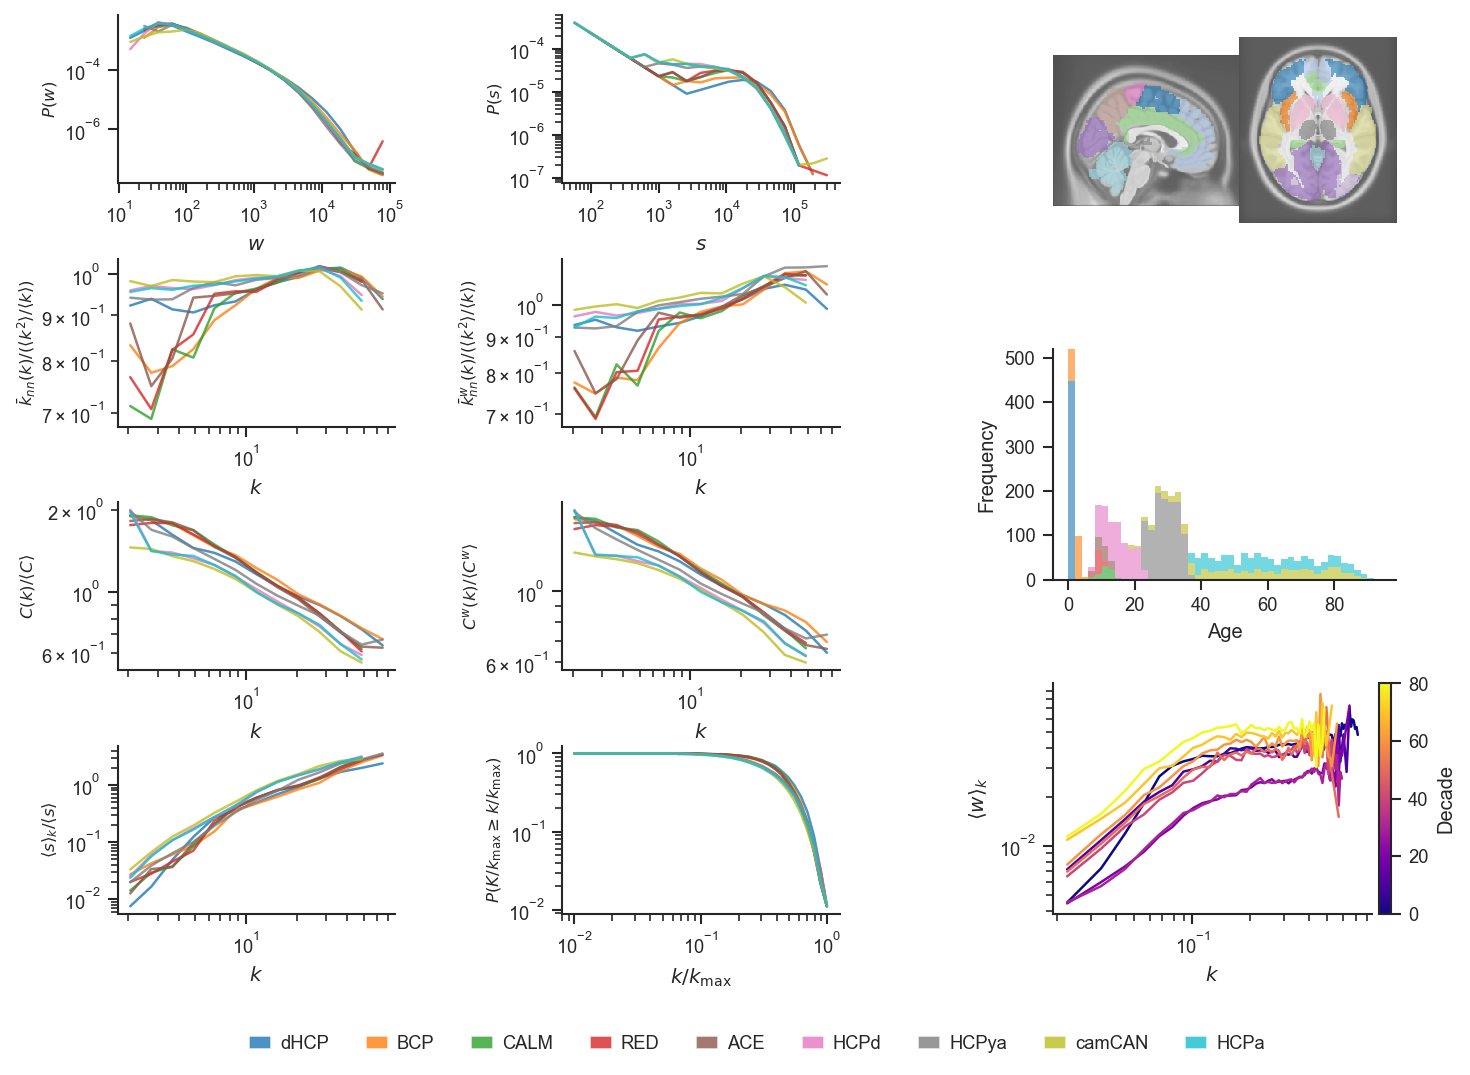

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import Patch
import seaborn as sns
from nilearn import plotting, datasets
from collections import defaultdict

# Configuración global de estilo
sns.set_theme(style='ticks', context='paper')

K_MAX = 89.0

# ── Funciones Auxiliares ──────────────────────────────────────────────────────

def get_wk_stats(sub_dec):
    """Calcula las estadísticas de w(k) por década."""
    wk_dec = defaultdict(list)
    for _, row in sub_dec.iterrows():
        A = row.connectome.copy()
        np.fill_diagonal(A, 0)
        if A.max() > 0:
            A = A / A.max()
        
        # Asume que node_metrics está definida en el entorno
        k, s, Yi, kYi, wi = node_metrics(A)
        v = k > 1
        for ki_raw in np.unique(k[v].astype(int)):
            m = k == ki_raw
            ki_norm = ki_raw / K_MAX
            wk_dec[ki_norm].append(A[m][A[m] > 0].mean() if A[m].sum() > 0 else np.nan)
            
    ks_norm = np.array(sorted(wk_dec.keys()))
    w_med = np.array([np.nanmedian(wk_dec[ki]) for ki in ks_norm])
    return ks_norm, w_med

def build_composite_figure(
    data, 
    left_accumulated,
    wk_calculated,    
    ds2col, 
    DS_NAMES, 
    atlas_nii_path,
    BINS_AGE=np.arange(0, 96, 2),
    figsize=(11, 8.5)
):
    """Ensambla los 4 paneles en una figura compacta."""
    fig = plt.figure(figsize=figsize)

    # 1. Master Grid Layout
    outer_gs = gridspec.GridSpec(2, 1, height_ratios=[1, 0.04], hspace=0.1)
    
    # Separación principal Izquierda/Derecha
    content_gs = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=outer_gs[0], width_ratios=[2.1, 1], wspace=0.40
    )
    
    # Separación interna de las columnas izquierdas
    left_gs = gridspec.GridSpecFromSubplotSpec(
        4, 2, subplot_spec=content_gs[0], hspace=0.45, wspace=0.60
    )
    right_gs = gridspec.GridSpecFromSubplotSpec(
        3, 1, subplot_spec=content_gs[1], hspace=0.45
    )

    # 2. Left Panel: Distributions (4x2)
    axs_left = [fig.add_subplot(left_gs[r, c]) for r in range(4) for c in range(2)]
    
    _PANEL_KEYS = ['pw', 'ps', 'knn_uw', 'knn_w', 'ck_uw', 'ck_w', 'sk', 'cpk']
    _XLABELS = [r'$w$', r'$s$', r'$k$', r'$k$', r'$k$', r'$k$', r'$k$', r'$k/k_{\max}$']
    _YLABELS = [
        r'$P(w)$', r'$P(s)$',
        r'$\bar{k}_{nn}(k)/(\langle k^2\rangle/\langle k\rangle)$',
        r'$\bar{k}_{nn}^w(k)/(\langle k^2\rangle/\langle k\rangle)$',
        r'$C(k)/\langle C\rangle$', r'$C^w(k)/\langle C^w\rangle$',
        r'$\langle s\rangle_k/\langle s\rangle$', r'$P(K/k_{\max}\geq k/k_{\max})$'
    ]

    for item in left_accumulated:
        acc, c, a, lw = item['acc'], item['color'], item['alpha'], item['lw']
        for ax, key in zip(axs_left, _PANEL_KEYS):
            if not acc.get(key):
                continue
            xs = np.array(sorted(acc[key]))
            med = np.array([np.median(acc[key][x]) for x in xs])
            ok = med > 0
            ax.loglog(xs[ok], med[ok], '-', lw=lw, alpha=a, color=c)

    for ax, xl, yl in zip(axs_left, _XLABELS, _YLABELS):
        ax.set_xlabel(xl)
        ax.set_ylabel(yl, fontsize=8, labelpad=2)
        sns.despine(ax=ax)

    # 3. Right Top: Brain ROI
    ax_brain = fig.add_subplot(right_gs[0])
    mni_template = datasets.fetch_icbm152_2009().t1
    plotting.plot_roi(
        atlas_nii_path,
        bg_img=mni_template,
        display_mode='xz',
        alpha=0.6,
        cmap='tab20',
        annotate=False,
        draw_cross=False,
        black_bg=False,
        colorbar=False,
        axes=ax_brain
    )

    # 4. Right Middle: Age Histogram
    ax_hist = fig.add_subplot(right_gs[1])
    bottoms = np.zeros(len(BINS_AGE) - 1)
    
    for ds in sorted(DS_NAMES.keys()):
        if ds not in data['dataset'].values:
            continue
        hist, _ = np.histogram(data[data.dataset == ds]['age'].values, bins=BINS_AGE)
        ax_hist.bar(
            BINS_AGE[:-1], hist, width=np.diff(BINS_AGE), bottom=bottoms,
            color=ds2col[ds], alpha=0.6, align='edge', linewidth=0
        )
        bottoms += hist

    ax_hist.set_xlabel('Age')
    ax_hist.set_ylabel('Frequency')
    ax_hist.set_xticks(np.arange(0, 100, 20))
    sns.despine(ax=ax_hist)

    # 5. Right Bottom: wk
    ax_wk = fig.add_subplot(right_gs[2])
    
    for item in wk_calculated:
        ax_wk.loglog(item['ks'], item['w_med'], '-', lw=1.2, color=item['color'])

    ax_wk.set_xlabel(r'$k$')
    ax_wk.set_ylabel(r'$\langle w \rangle_{k}$')
    sns.despine(ax=ax_wk)

    valid_decades = [d for d in data['decade'].unique() if d <= 80]
    norm_wk = mcolors.Normalize(vmin=min(valid_decades), vmax=max(valid_decades))
    sm_wk = cm.ScalarMappable(cmap=plt.cm.plasma, norm=norm_wk)
    sm_wk.set_array([])
    cbar = fig.colorbar(sm_wk, ax=ax_wk, orientation='vertical', pad=0.02, fraction=0.05)
    cbar.set_label('Decade')

    # 6. Unified Legend (Bottom)
    ax_leg = fig.add_subplot(outer_gs[1])
    ax_leg.set_axis_off()
    
    handles = [Patch(facecolor=ds2col[ds], alpha=0.8, label=DS_NAMES[ds]) 
               for ds in sorted(DS_NAMES.keys()) if ds in data['dataset'].values]
    
    ax_leg.legend(
        handles=handles, 
        loc='upper center', 
        bbox_to_anchor=(0.5, -0.6), 
        ncol=max(1, len(handles)), 
        frameon=False, 
        handlelength=1.2, 
        handletextpad=0.5
    )

    return fig


# ── Ejecución Principal ───────────────────────────────────────────────────────

if __name__ == "__main__":
    # 1. Pre-calculate Left Panel Data (Distributions)
    left_accumulated = []
    for ds in FILTER_DS:
        subjects_iter = data[data.dataset == ds].itertuples()
        # Asume que accumulate_distributions está definida en el entorno
        acc = accumulate_distributions(subjects_iter)
        left_accumulated.append({
            'acc': acc,
            'color': ds2col[ds],
            'alpha': 0.8,
            'lw': 1.2
        })

    # 2. Pre-calculate Right Bottom Panel Data (w(k) per decade)
    wk_calculated = []
    all_decades = sorted(data['decade'].unique())
    valid_decades = [d for d in all_decades if len(data[data.decade == d]) >= MIN_N and d <= 80]

    norm_wk = mcolors.Normalize(vmin=min(valid_decades), vmax=max(valid_decades))
    cmap_wk = plt.cm.plasma

    for dec in valid_decades:
        sub_dec = data[data.decade == dec]
        ks_norm, w_med = get_wk_stats(sub_dec)
        wk_calculated.append({
            'ks': ks_norm,
            'w_med': w_med,
            'color': cmap_wk(norm_wk(dec))
        })

    # 3. Construir y guardar la figura
    fig = build_composite_figure(
        data=data,
        left_accumulated=left_accumulated,
        wk_calculated=wk_calculated,
        ds2col=ds2col,
        DS_NAMES=DS_NAMES,
        atlas_nii_path='./preprocdata/aal-SPM12/aal/atlas/AAL.nii',
        BINS_AGE=np.arange(0, 96, 2)
    )

    plt.savefig('borradorv2/panel1_composite_final.pdf', bbox_inches='tight', dpi=300)
    plt.show()

# Figura 2

# Figura 3

# Supplementary

## Fig 1 supplementary. Con greps